# Synthetic Ground-Truth Training

Validation experiment: generate a voltage trace from **known** AdEx parameters,
then attempt to recover those parameters via gradient-based training.

This isolates the training pipeline from experimental noise — if training works here,
any failure on real data points to data/model mismatch rather than pipeline bugs.

**Setup:**
- Ground truth parameters: Naud "adaptation" set (configurable)
- Current stimulus: reuses experimental current waveform for realism
- Initial parameters: small perturbation (~15%) from ground truth
- Two-stage training: Stage 1 (Guarino, coarse) → Stage 2 (fine-tune adaptation)

In [93]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    SoftDTWLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_soft_dtw_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters & Current Stimulus

Load the experimental current waveform (for realistic stimulus shape),
then define ground truth AdEx parameters.

In [94]:
# --- Load experimental current waveform (we only use the current, not the voltage) ---
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

exp_trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)
exp_cropped = crop_to_stim_window(exp_trace, max_duration_ms=300.0, padding_ms_before=100)

print(f"Current waveform: {exp_cropped.n_samples} samples, dt={exp_cropped.dt_ms:.3f} ms")
print(f"Stim window: idx {exp_cropped.stim_start_idx} - {exp_cropped.stim_end_idx} ({exp_cropped.stim_duration_ms:.1f} ms)")
print(f"Stim current: {exp_cropped.stim_current_pA:.1f} pA")

Current waveform: 4000 samples, dt=0.100 ms
Stim window: idx 1000 - 4000 (300.0 ms)
Stim current: 421.3 pA


In [95]:
# --- Ground truth parameters (change this to test different regimes) ---
GROUND_TRUTH_BASE = "adaptation"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
ground_truth_params["v_threshold"] = 0.0
ground_truth_params["delta_T"] = 3.0

# Override values that would sit at parameter bounds (which prevents perturbation
# and makes recovery trivial/impossible). Choose values well inside PARAM_BOUNDS.
ground_truth_params["v_reset"] = -52.0   # bounds: [-60, -45], midpoint -52.5
ground_truth_params["E_L"] = -72.0       # bounds: [-75, -68], midpoint -71.5
ground_truth_params["v_T"] = -45.0       # bounds: [-60, -30], well inside
ground_truth_params["tau_w"] = 200.0     # bounds: [20, 320], well inside

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: adaptation
Ground truth parameters:
  C_m             200.000  [180.0, 220.0]  (50% into range)
  g_L              12.000  [9.0, 13.0]  (75% into range)
  E_L             -72.000  [-75.0, -68.0]  (43% into range)
  v_T             -45.000  [-60.0, -30.0]  (50% into range)
  delta_T           3.000  [2, 20.0]  (6% into range)
  v_reset         -52.000  [-60.0, -45.0]  (53% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w           200.000  [20.0, 320.0]  (60% into range)
  a                 2.000  [-10.0, 3.0]  (92% into range)
  b                60.000  [0.0, 65.0]  (92% into range)
  I               500.000


## 2. Generate Synthetic Voltage Trace

Simulate with ground truth parameters and the experimental current waveform,
then package the result as `TraceData` (same structure as experimental data).

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Ground truth simulation: 4 spikes, 10.0 Hz

Synthetic TraceData: 4000 samples, 4 spikes
Spike times: [131.9 164.8 242.2 379.9] ms
Stim window: idx 1000 - 4000 (300.0 ms)


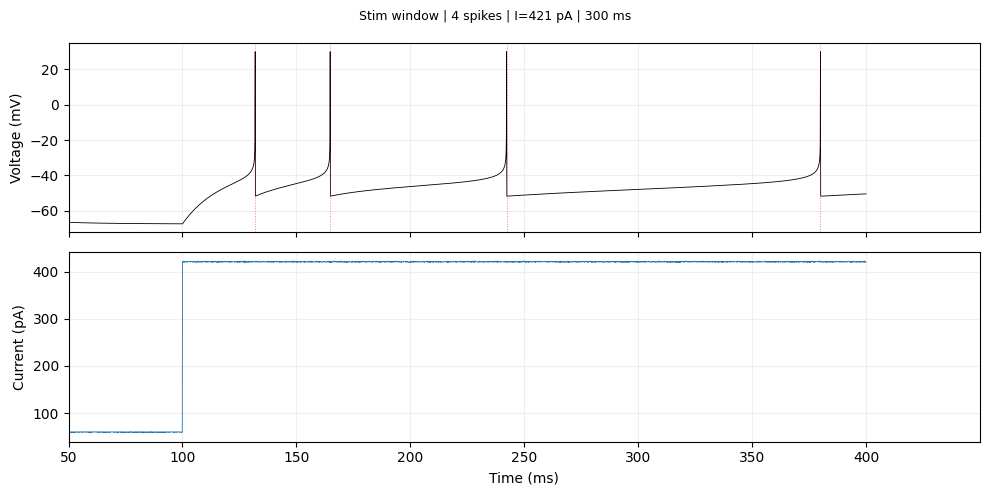

In [96]:
# --- Simulate ground truth ---
sim_gt = simulate_with_current_trace(
    params=ground_truth_params,
    current_trace_pA=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    use_surrogate=False,  # exact simulation, no surrogate needed
)

print(f"Ground truth simulation: {sim_gt.n_spikes} spikes, {sim_gt.firing_rate_hz:.1f} Hz")

# --- Package as TraceData (same structure as experimental data) ---
# Jaxley may return one extra timestep; truncate to match the input current length
n = len(exp_cropped.time)
voltage_gt = sim_gt.voltage[:n].copy()

# Use spike times from the simulation's internal spike trace, NOT from detect_spikes().
# Jaxley resets voltage within the same timestep, so the recorded voltage never crosses
# the detection threshold — but the spike indicator is set correctly.
spike_times = sim_gt.spike_times

# Inject spike peaks into the voltage trace at known spike times.
# Jaxley's same-timestep reset means recorded voltage never shows the spike peak.
# Real experimental recordings show full peaks, so we restore them to make the
# synthetic data look like experimental data for feature extraction.
SPIKE_PEAK_MV = 30.0
for st in spike_times:
    idx = int(st / exp_cropped.dt_ms)
    if 0 <= idx < len(voltage_gt):
        voltage_gt[idx] = SPIKE_PEAK_MV

data = TraceData(
    time=exp_cropped.time,
    voltage=voltage_gt,
    current=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    spike_times=spike_times,
    stim_start_idx=exp_cropped.stim_start_idx,
    stim_end_idx=exp_cropped.stim_end_idx,
    stim_current_pA=exp_cropped.stim_current_pA,
)

print(f"\nSynthetic TraceData: {data.n_samples} samples, {data.n_spikes} spikes")
print(f"Spike times: {data.spike_times.round(1)} ms")
print(f"Stim window: idx {data.stim_start_idx} - {data.stim_end_idx} ({data.stim_duration_ms:.1f} ms)")

trace_stim_window_plot(data);


## 3. Perturbed Initial Parameters

Create initial parameters by adding ~15% noise to the ground truth.
This simulates the real scenario where we don't know the true values.

In [97]:
PERTURBATION = 0.15  # relative perturbation (15%)

# C_m, g_L, E_L, v_T, delta_T, v_reset, v_threshold, tau_w, a, b
# TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T"]
TRAINABLE_STAGE1 = ["C_m"]
TRAINABLE_STAGE2 = []


def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        # Scale noise by parameter range to handle params near zero (e.g. a=0)
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = list(set(TRAINABLE_STAGE1 + TRAINABLE_STAGE2))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
C_m               200.000      200.363     0.9%


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Initial simulation: 4 spikes (target: 4)


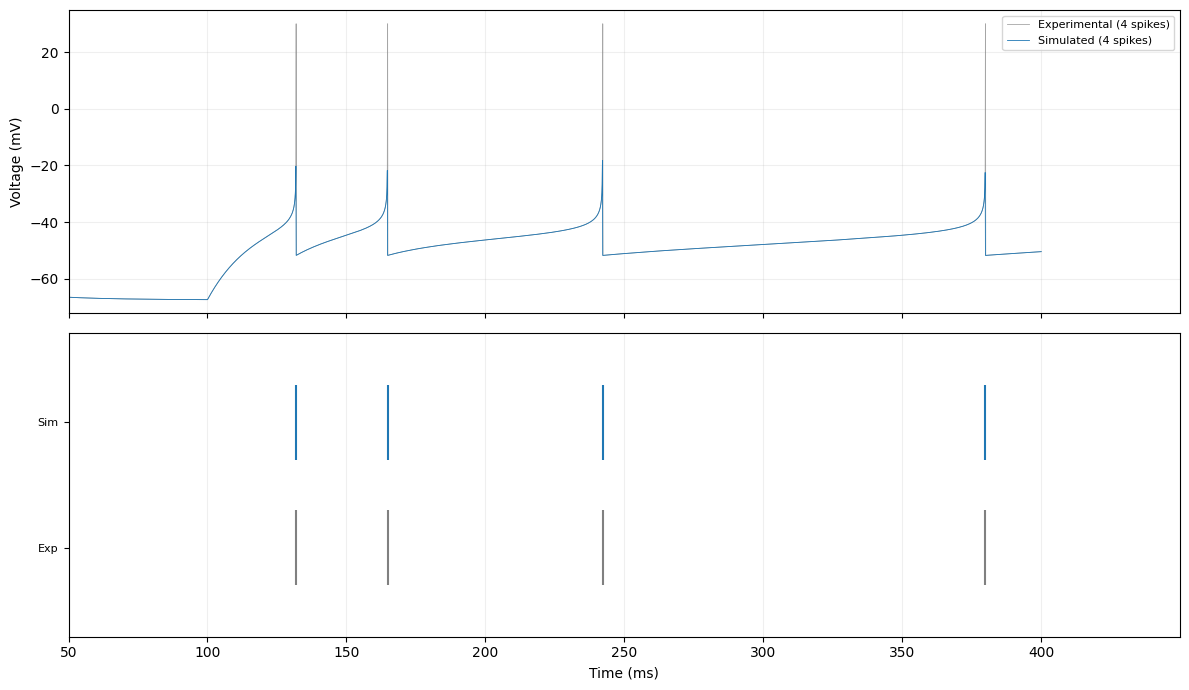

In [98]:
# Simulate with perturbed initial parameters to see the starting point
sim_init = simulate_with_current_trace(
    # params=initial_params,
    params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")
fit_comparison_plot(data, sim_init);

## 4. Stage 1 — Guarino Loss (Coarse Feature Matching)

In [99]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)
target_voltage = jnp.array(data.voltage)
stim_end_index = data.stim_end_idx

# --- Stage 1 config ---
config_stage1 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.01,
    n_epochs=75,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=20,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    # initial_params=initial_params,
    initial_params=ground_truth_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=config_stage1,
    trainable_params=TRAINABLE_STAGE1,
)

# Extract target features for Guarino loss
exp_features = extract_experimental_features(
    voltage_trace=target_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
)

loss_fn_stage1 = make_guarino_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
    loss_config=GuarinoLossConfig(
        weight_t_first=1.0,
        weight_t_second=2.0,
        weight_t_third=3.0,
        weight_t_last=4.0,
        weight_firing_freq=1.0,
        weight_spike_count=0.1,
    ),
)

print(f"Initial Guarino loss: {float(loss_fn_stage1(trainable_params1)):.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Initial Guarino loss: 0.2054


In [100]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=config_stage1,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Training: optimizer=polyak lr=0.01 epochs=75 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=0.205356 | grad_norm=4.76e-05 | lr=2.05e-03 | C_m=199.9954
Epoch   20 | loss=0.205357 | grad_norm=7.71e-06 | lr=2.05e-03 | C_m=199.9510
Epoch   40 | loss=0.205356 | grad_norm=1.94e-05 | lr=2.05e-03 | C_m=199.9461
Epoch   60 | loss=0.205356 | grad_norm=8.73e-06 | lr=2.05e-03 | C_m=199.9265
Training complete: final_loss=0.205356 best_loss=0.205355 (epoch 45) total_time=38.0s mean_epoch=506.9ms lr=2.05e-03->2.05e-03 [returning best]



Stage 1 complete.
  Best loss:   0.2054
  Total time:  38.0 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 1: 4 spikes (target: 4)
Gamma = 1.000


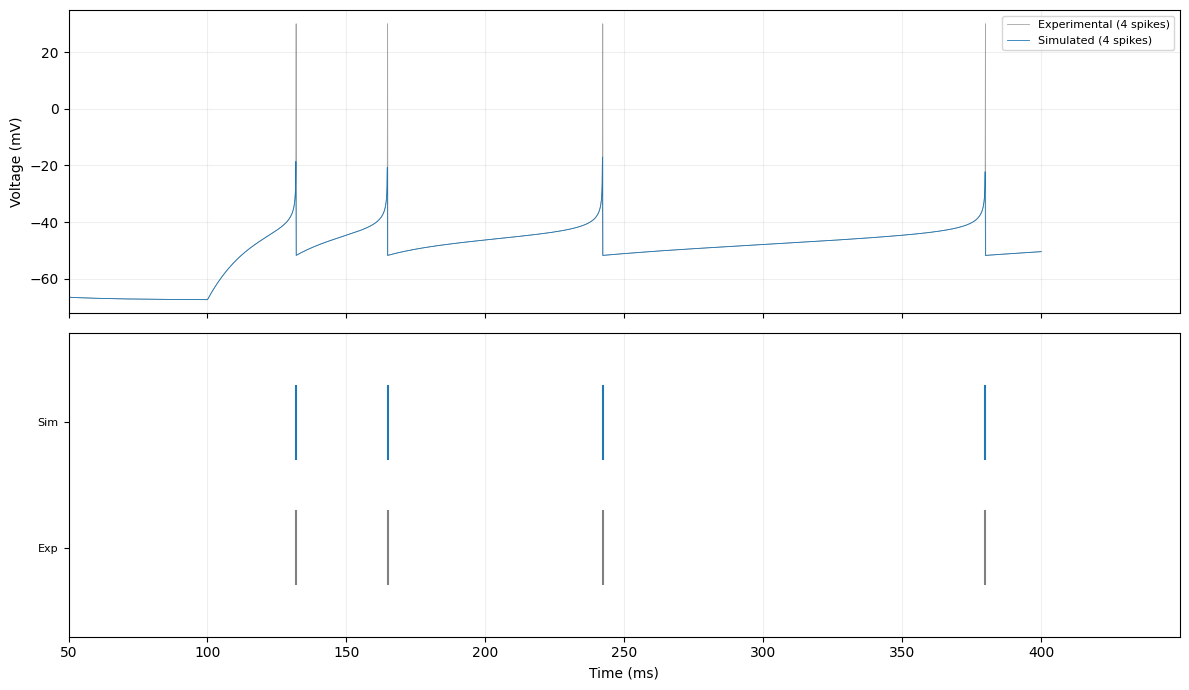

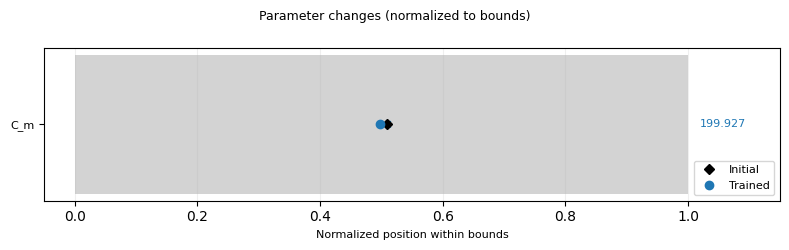

In [101]:
# Evaluate stage 1
trained_s1 = result_stage1.get_params_dict()
params_after_s1 = dict(initial_params)
params_after_s1.update(trained_s1)

sim_stage1 = simulate_with_current_trace(
    params=params_after_s1,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=5,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1);

## 5. Stage 2 — Fine-Tuning (Adaptation Parameters)

In [102]:
# Stage 2 starts from stage 1's trained parameters
stage2_params = dict(initial_params)
stage2_params.update(result_stage1.get_params_dict())

print("Stage 2 initial parameters (from stage 1):")
for k, v in result_stage1.get_params_dict().items():
    gt = ground_truth_params.get(k, float("nan"))
    print(f"  {k:<12} {v:>10.3f}  (GT: {gt:.3f})")

# --- Stage 2 config ---
config_stage2 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=50,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=20,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# Re-create cell for stage 2
cell2, data_stimuli2, t_max2, trainable_params2 = setup_trainable_cell(
    initial_params=stage2_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=config_stage2,
    trainable_params=TRAINABLE_STAGE2,
)

# Build experimental spike train for Van Rossum distance
exp_spike_train = spike_train_from_voltage(
    target_voltage, threshold_mv=0.0, dt_ms=data.dt_ms
)
print(f"\nTarget spike train: {int(jnp.sum(exp_spike_train))} spikes detected")

loss_fn_stage2 = make_soft_dtw_loss_fn(
    cell=cell2,
    data_stimuli=data_stimuli2,
    t_max=t_max2,
    dt_ms=data.dt_ms,
    exp_voltage=target_voltage,
    stim_end_index=stim_end_index,
    loss_config=SoftDTWLossConfig(spike_peak_mv=35),
)

print(f"Initial Stage 2 loss: {float(loss_fn_stage2(trainable_params2)):.4f}")

Stage 2 initial parameters (from stage 1):
  C_m             199.927  (GT: 200.000)
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.

Target spike train: 4 spikes detected
Initial Stage 2 loss: 4.5068


In [103]:
result_stage2 = train(
    loss_fn=loss_fn_stage2,
    trainable_params=trainable_params2,
    config=config_stage2,
    initial_params=stage2_params,
)

print(f"\nStage 2 complete.")
print(f"  Best loss:   {result_stage2.best_loss:.4f}")
print(f"  Total time:  {result_stage2.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=50 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=4.506774 | grad_norm=0.00e+00 | lr=2.25e-02 | 
Epoch   20 | loss=4.506774 | grad_norm=0.00e+00 | lr=2.25e-02 | 
Epoch   40 | loss=4.506774 | grad_norm=0.00e+00 | lr=2.25e-02 | 
Training complete: final_loss=4.506774 best_loss=4.506774 (epoch 0) total_time=15.0s mean_epoch=300.7ms lr=2.25e-02->2.25e-02 [returning best]



Stage 2 complete.
  Best loss:   4.5068
  Total time:  15.0 s


## 6. Results — Parameter Recovery

In [104]:
# Final simulation with stage 2 parameters
trained_s2 = result_stage2.get_params_dict()
params_final = dict(initial_params)
params_final.update(trained_s1)
params_final.update(trained_s2)

sim_final = simulate_with_current_trace(
    params=params_final,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Final simulation: {sim_final.n_spikes} spikes (target: {data.n_spikes})")

if sim_final.n_spikes > 0 and data.n_spikes > 0:
    cf_final = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_final.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=5
    )
    print(f"Coincidence factor Gamma = {cf_final.gamma:.3f} (target > 0.5)")
else:
    cf_final = None
    print("Coincidence factor: N/A (no spikes)")

if cf_s1 is not None:
    gamma_s2 = f"{cf_final.gamma:.3f}" if cf_final else "N/A"
    print(f"\nStage 1 Gamma: {cf_s1.gamma:.3f} -> Stage 2 Gamma: {gamma_s2}")

/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Final simulation: 4 spikes (target: 4)
Coincidence factor Gamma = 1.000 (target > 0.5)

Stage 1 Gamma: 1.000 -> Stage 2 Gamma: 1.000


In [105]:
# --- Parameter recovery table: compare final to ground truth ---
print("Parameter Recovery: Ground Truth vs Trained")
print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Final':>12} {'Error (%)':>10}")
print("-" * 62)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    final = params_final.get(k, init)
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(final - gt) / (bounds.max - bounds.min) * 100
    init_err = abs(init - gt) / (bounds.max - bounds.min) * 100
    arrow = "<-" if err_pct < init_err else "->"
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {final:>12.3f} {err_pct:>9.1f}% {arrow}")

Parameter Recovery: Ground Truth vs Trained
Parameter    Ground Truth      Initial        Final  Error (%)
--------------------------------------------------------------
C_m               200.000      200.363      199.927       0.2% <-


## 7. Plots

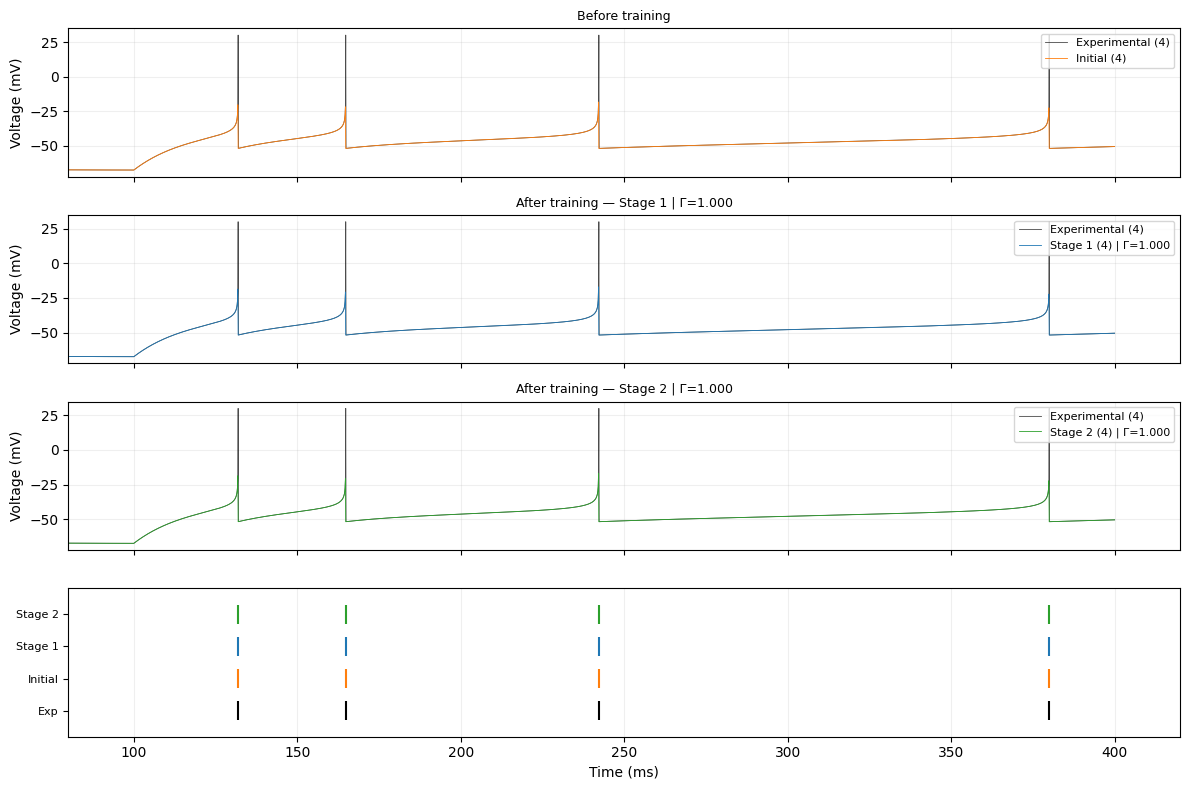

In [106]:
fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1, sim_final],
    coincidence=[cf_s1, cf_final],
    labels=["Stage 1", "Stage 2"],
);

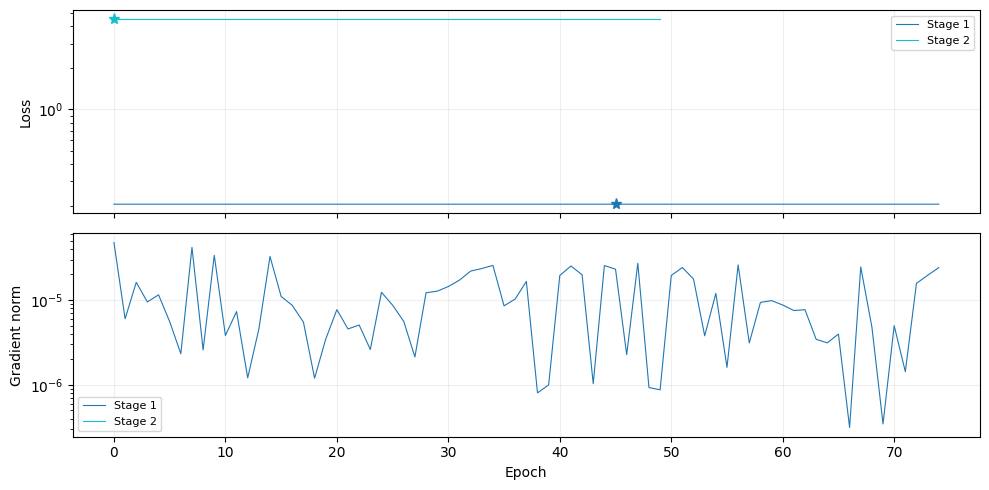

In [107]:
training_comparison_plot(
    [result_stage1, result_stage2],
    labels=["Stage 1", "Stage 2"],
    show_grad_norms=True,
);

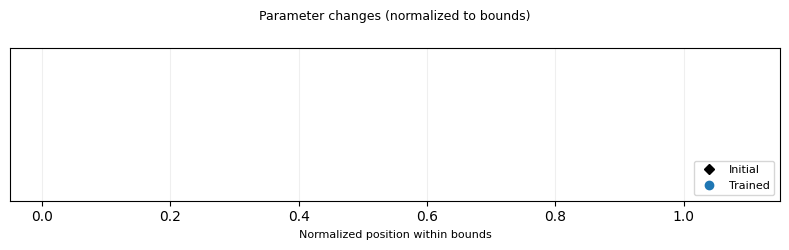

In [108]:
parameter_comparison_plot(result_stage2);

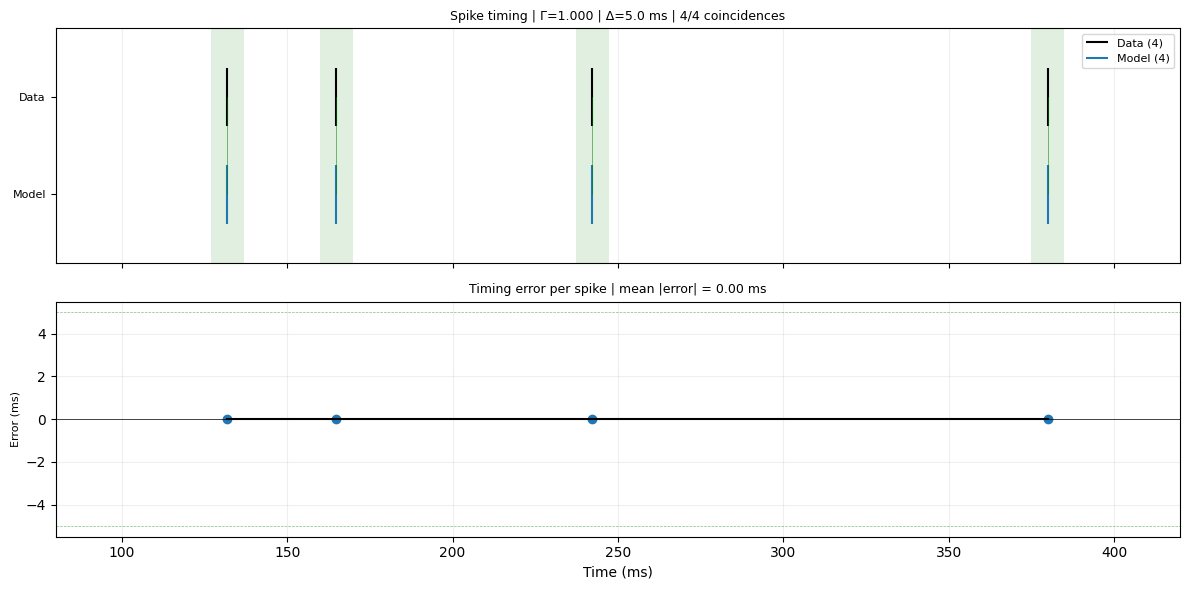

In [109]:
if cf_final is not None:
    spike_timing_plot(data, sim_final, cf_final)
else:
    print("Spike timing plot skipped (no spikes)")